**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('C:\WORKS\PROJECTS\Invoice_Intelligence\data\inventory.db')
tables = pd.read_sql_query("select name from sqlite_master where TYPE = 'table'",conn)
tables

for table in tables['name']:
    print('-'*50, f'{table}','-'*50)
    print('count of records: ',pd.read_sql(f"SELECT COUNT(*) as count FROM {table}",conn)['count'].values[0])
    display(pd.read_sql(f"select * from {table} limit 5\n",conn))

-------------------------------------------------- begin_inventory --------------------------------------------------
count of records:  206529


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


-------------------------------------------------- end_inventory --------------------------------------------------
count of records:  224489


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


-------------------------------------------------- purchases --------------------------------------------------
count of records:  2372474


...

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


-------------------------------------------------- sales --------------------------------------------------
count of records:  12825363


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


-------------------------------------------------- vendor_invoice --------------------------------------------------
count of records:  5543


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


**WE USE PURCHASES, AND VENDOR_INVOICE TABLE**
Since these two tables contain the necessary invoice-related features to train a classification model

In [3]:
purchase_agg_df = pd.read_sql_query('''
SELECT 
POnumber,
COUNT(DISTINCT Brand) as total_brands,
SUM(Quantity) as total_item_quantity,
SUM(dollars) AS total_item_dollars,
ROUND(AVG(julianday(ReceivingDate) - julianday(PODate)), 2)  as avg_receiving_delay
FROM purchases
GROUP BY POnumber
''',conn)
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.61
1,8107,2,24,348.72,12.50
2,8108,165,8466,60281.13,12.63
3,8109,23,2246,14298.09,12.63
4,8110,183,8086,56493.23,12.70
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.87
5539,13658,111,14115,102949.38,5.02
5540,13659,13,338,2492.20,4.74
5541,13660,12,195,2599.66,4.61


In [4]:
pd.read_sql_query('''
SELECT  
PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay              
FROM vendor_invoice vi      
''',conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [5]:
df = pd.read_sql_query('''                   
WITH purchase_agg AS (
    SELECT 
    POnumber,
    COUNT(DISTINCT Brand) as total_brands,
    SUM(Quantity) as total_item_quantity,
    SUM(dollars) AS total_item_dollars,
    ROUND(AVG(julianday(ReceivingDate) - julianday(PODate)), 2)  as avg_receiving_delay
    FROM purchases
    GROUP BY POnumber               
)
                  
SELECT
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay
                   
FROM vendor_invoice vi 
LEFT JOIN purchase_agg pa
on vi.PONumber = pa.PONumber

''',conn)
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.00
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.33
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.00
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.61
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.75
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.87
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.05
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.00
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.05


In [6]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [7]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

# Generating Target Labels for Supervised Learning

In the absence of pre-existing risk labels, I applied a rule-based heuristic to flag invoices for manual review. This approach—based on invoice discrepancies and receiving delays—serves exclusively as a mechanism to bootstrap my training dataset.

## Note on Production Readiness:

I do not use this static, rule-based logic for inference in the final deployment. Instead, I trained the downstream machine learning pipeline (Random Forest Classifier) to automatically learn and extract these complex patterns from the features. Once trained, my model identifies potential risks in unseen data independently, removing the need for manual, hard-coded rules and ensuring the system is scalable for real-world application.

In [10]:
def create_invoice_risk_label(row):
     # invoice total mismatch with  item-level total
     if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1
     # Abornormally high receiving delay
     if row["avg_receiving_delay"] > 10:
        return 1
     
     return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis = 1)
df["flag_invoice"].value_counts()

flag_invoice
0    3695
1    1848
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

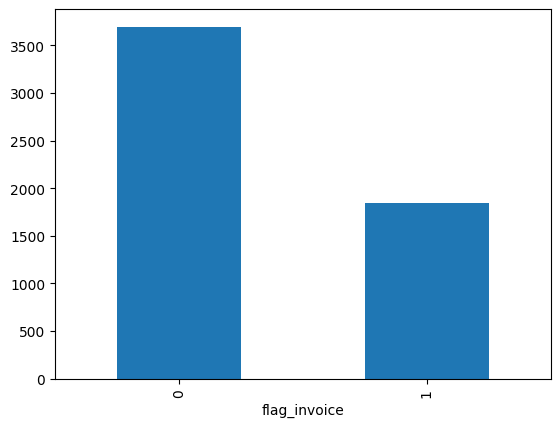

In [11]:
df['flag_invoice'].value_counts().plot(kind = 'bar')

In [ ]:
# creating correlation plot



<bound method DataFrame.corr of       PONumber  invoice_quantity  invoice_dollars  Freight  \
0         8124                 6           214.26     3.47   
1         8137                15           140.55     8.57   
2         8169                 5           106.60     4.61   
3         8106             10100        137483.78  2935.20   
4         8170              1935         15527.25   429.20   
...        ...               ...              ...      ...   
5538     13626                90          1563.00     8.60   
5539     13661              4617         37300.48   186.50   
5540     13643              9848        202815.78   932.95   
5541     13602             24747        149007.56   819.54   
5542     13574               437          3608.11    16.60   

      days_po_to_invoice  days_to_pay  total_brands  total_item_quantity  \
0                   14.0         43.0             1                    6   
1                   16.0         45.0             2                   1